In [1]:
%cd ..

/home/ricka/Git/GitHub/RickArko/kaggle/comp/kcom-pokemon


# Match Analysis — Pokemon TCG Agent Performance

Load aggregated Parquet tables from `make match-all` and explore agent behaviour, win-rate trends, prize-race dynamics, decision patterns, deck-type matchups, and **synthesize winning strategies** from top agents.

## Setup

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.max_open_warning"] = 0

DATA = Path("data/matches/aggregated")

OPT_NAMES = {7: "Play", 8: "Attach", 9: "Evolve", 10: "Ability",
             12: "Retreat", 13: "Attack", 14: "End"}
SEL_NAMES = {0: "MAIN", 1: "CARD", 4: "ENERGY", 8: "COUNT", 9: "YESNO"}

In [3]:
try:
    results = pd.read_parquet(DATA / "results.parquet")
    frames = pd.read_parquet(DATA / "frames.parquet")
    turns = pd.read_parquet(DATA / "turn_summary.parquet")
    print(f"results: {len(results)} matches")
    print(f"frames:  {len(frames)} decision points")
    print(f"turns:   {len(turns)} turn-rows")
except FileNotFoundError:
    print("No aggregated data found. Run: make match-all")
    results = frames = turns = None

results: 1800 matches
frames:  15413 decision points
turns:   4908 turn-rows


In [4]:
# Shared prep
if results is not None:
    clean = results[results["winner"].isin([0, 1])].copy()
    clean["match_id"] = clean["match_id"].astype(str)
    wins_map = clean.set_index("match_id")["winner"].to_dict()

    f = frames.merge(clean[["match_id", "agent0", "agent1", "arch0", "arch1"]],
                     on="match_id", how="inner")
    f["player_agent"] = np.where(f["player"] == 0, f["agent0"], f["agent1"])
    f["act"] = f["chosen_type"].map(OPT_NAMES).fillna("Other")
    f["winner"] = f["match_id"].map(wins_map)
    f["agent_won"] = (f["player"] == f["winner"]).astype(int)

    main = f[f["select_type"] == 0].copy()
    print(f"MAIN decisions: {len(main)}")
    print(f"Agents: {sorted(main['player_agent'].unique())}")

MAIN decisions: 9030
Agents: ['exp001_baseline', 'exp002_lucario_heuristic', 'exp003_lucario_mcts', 'exp004_dragapult_mcts', 'exp005_lucario_opp_mcts', 'random']


---
## 1. Win-Rate Matrix

Heatmap of agent A (row) vs agent B (column) win percentages.

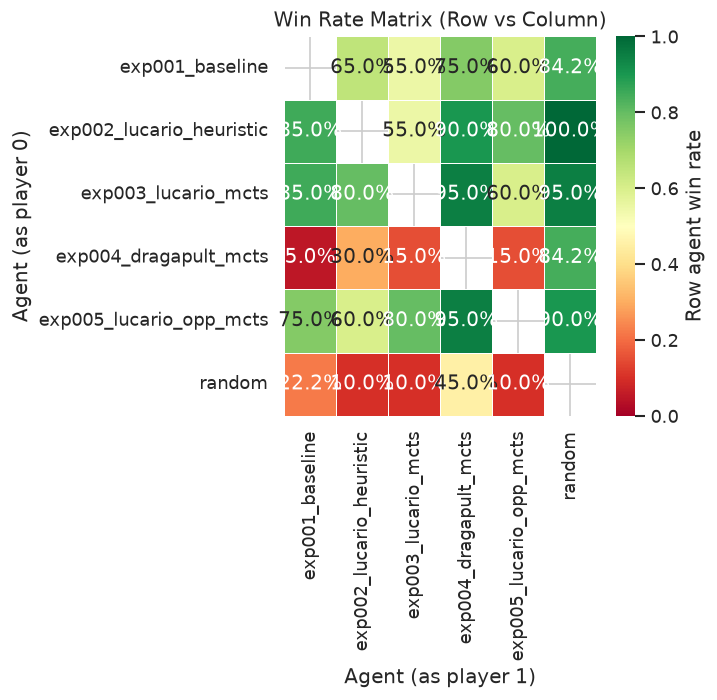

In [5]:
if results is not None:
    wins = results[results["winner"].isin([0, 1])].copy()
    wins["agent0_won"] = (wins["winner"] == 0).astype(int)
    matrix = wins.pivot_table(
        index="agent0", columns="agent1", values="agent0_won", aggfunc="mean"
    )
    plt.figure(figsize=(max(6, len(matrix.columns)), max(4, len(matrix.index))))
    sns.heatmap(matrix, annot=True, fmt=".1%", cmap="RdYlGn", vmin=0, vmax=1,
                linewidths=0.5, cbar_kws={"label": "Row agent win rate"})
    plt.title("Win Rate Matrix (Row vs Column)")
    plt.xlabel("Agent (as player 1)")
    plt.ylabel("Agent (as player 0)")
    plt.tight_layout()
    plt.show()

---
## 2. Deck-Type Matchup Analysis

Cross-tabulate deck archetypes to see which builds counter which.

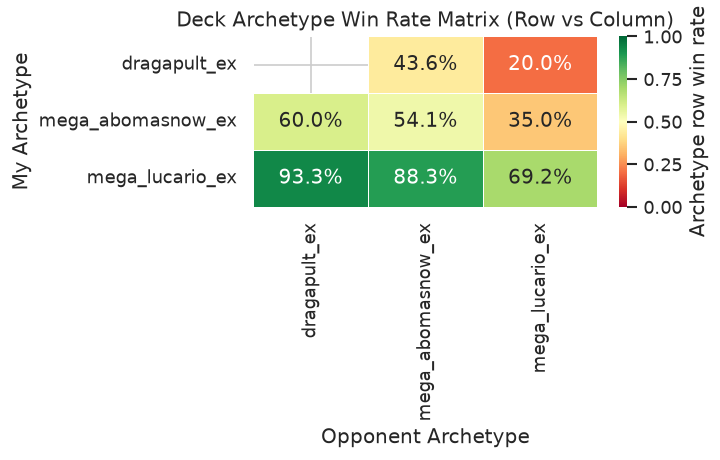

Matchups per pair:
arch1              dragapult_ex  mega_abomasnow_ex  mega_lucario_ex
arch0                                                              
dragapult_ex                NaN               39.0             60.0
mega_abomasnow_ex          40.0               37.0            120.0
mega_lucario_ex            60.0              120.0            120.0


In [6]:
if results is not None and "arch0" in results.columns:
    valid = results[results["winner"].isin([0, 1])].copy()
    valid["arch0_won"] = (valid["winner"] == 0).astype(int)
    arch_matrix = valid.pivot_table(
        index="arch0", columns="arch1", values="arch0_won", aggfunc=["mean", "count"]
    )
    wr = arch_matrix["mean"]
    plt.figure(figsize=(max(6, len(wr.columns)), max(4, len(wr.index))))
    sns.heatmap(wr, annot=True, fmt=".1%", cmap="RdYlGn", vmin=0, vmax=1,
                linewidths=0.5, cbar_kws={"label": "Archetype row win rate"})
    plt.title("Deck Archetype Win Rate Matrix (Row vs Column)")
    plt.xlabel("Opponent Archetype")
    plt.ylabel("My Archetype")
    plt.tight_layout()
    plt.show()
    print("Matchups per pair:")
    print(arch_matrix["count"].to_string())
else:
    print("arch columns not available. Run: make match-aggregate")

In [7]:
if results is not None and "deck0" in results.columns:
    from pokemon.card_db import get_card_db
    from pokemon.deck_analysis import card_frequencies, deck_summary
    db = get_card_db(use_engine=False)

    comps = []
    for _, row in results.iterrows():
        for side in ["0", "1"]:
            deck = row.get(f"deck{side}")
            arch = row.get(f"arch{side}", "unknown")
            if deck is None or not isinstance(deck, list):
                continue
            summary = deck_summary(deck, db)
            comps.append({"archetype": arch, "energy_pct": summary["energy_pct"],
                          "pokemon_pct": summary["pokemon_pct"],
                          "trainer_pct": summary["trainer_pct"]})
    if comps:
        df_comp = pd.DataFrame(comps)
        comp_plot = df_comp.groupby("archetype")[["energy_pct", "pokemon_pct", "trainer_pct"]].mean()
        plt.figure(figsize=(10, 5))
        comp_plot.plot(kind="bar", stacked=True, colormap="Set2", ax=plt.gca())
        plt.title("Average Deck Composition by Archetype")
        plt.ylabel("Percentage of Deck")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
else:
    print("deck columns not in results table. Run: make match-aggregate")

---
## 3. Winning Strategy Mining

Analyse what top agents (exp003 MCTS, exp005 Opp-MCTS, exp002 Heuristic) do differently from weaker ones, and what distinguishes their wins from losses.

### 3a. Agent Leaderboard

In [8]:
if results is not None:
    c = results[results["winner"].isin([0, 1])]
    wr_data = []
    for agent in sorted(c["agent0"].unique()):
        as_p0 = c[c["agent0"] == agent]
        as_p1 = c[c["agent1"] == agent]
        wins = (as_p0["winner"] == 0).sum() + (as_p1["winner"] == 1).sum()
        total = len(as_p0) + len(as_p1)
        wr_data.append({"agent": agent, "wins": wins, "total": total,
                        "win_rate": wins / total * 100 if total else 0.0})
    leaderboard = pd.DataFrame(wr_data).sort_values("win_rate", ascending=False)
    print(leaderboard.to_string(index=False, float_format=lambda x: f"{x:.1f}"))

                   agent  wins  total  win_rate
     exp003_lucario_mcts   140    200      70.0
 exp005_lucario_opp_mcts   135    200      67.5
exp002_lucario_heuristic   133    200      66.5
         exp001_baseline   111    197      56.3
   exp004_dragapult_mcts    49    199      24.6
                  random    28    196      14.3


### 3b. Action Profile: What winning agents do differently

Compare the distribution of actions (Attack / Play / Evolve / Retreat / End / Attach) between top agents and weaker ones.

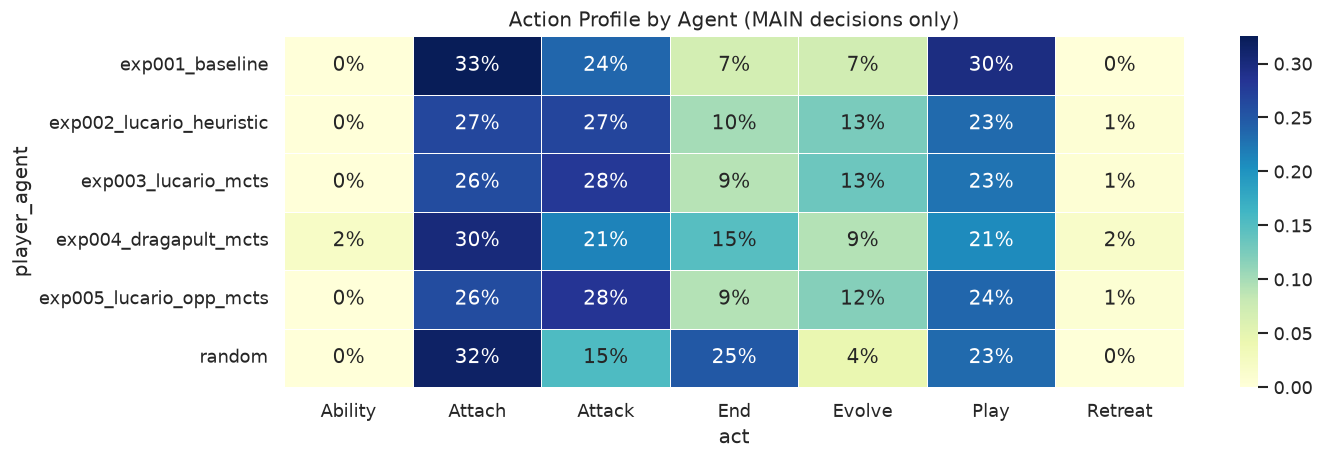

In [9]:
if 'main' in dir():
    profile = main.groupby(["player_agent", "act"]).size().unstack(fill_value=0)
    profile_pct = profile.div(profile.sum(axis=1), axis=0)

    plt.figure(figsize=(12, max(4, len(profile_pct) * 0.5)))
    sns.heatmap(profile_pct, annot=True, fmt=".0%", cmap="YlGnBu", linewidths=0.5)
    plt.title("Action Profile by Agent (MAIN decisions only)")
    plt.tight_layout()
    plt.show()

In [10]:
if 'main' in dir():
    for agent in ["exp003_lucario_mcts", "exp002_lucario_heuristic", "exp005_lucario_opp_mcts"]:
        sub = main[main["player_agent"] == agent]
        if len(sub) < 10:
            continue
        wl = sub.groupby(["agent_won", "act"]).size().unstack(fill_value=0)
        wl_pct = wl.div(wl.sum(axis=1), axis=0)
        print(f"\n=== {agent} ===")
        print("  When WINNING (agent_won=1)  vs  When LOSING (agent_won=0)")
        comparison = pd.DataFrame({
            "win%": wl_pct.loc[1] if 1 in wl_pct.index else 0,
            "lose%": wl_pct.loc[0] if 0 in wl_pct.index else 0,
        }).fillna(0)
        comparison["delta"] = comparison["win%"] - comparison["lose%"]
        print(comparison.round(3).to_string())


=== exp003_lucario_mcts ===
  When WINNING (agent_won=1)  vs  When LOSING (agent_won=0)
          win%  lose%  delta
act                         
Attach   0.249  0.294 -0.045
Attack   0.277  0.286 -0.008
End      0.100  0.067  0.033
Evolve   0.161  0.067  0.094
Play     0.209  0.272 -0.063
Retreat  0.003  0.013 -0.010

=== exp002_lucario_heuristic ===
  When WINNING (agent_won=1)  vs  When LOSING (agent_won=0)
          win%  lose%  delta
act                         
Attach   0.246  0.313 -0.067
Attack   0.269  0.265  0.004
End      0.110  0.079  0.031
Evolve   0.159  0.048  0.111
Play     0.213  0.282 -0.069
Retreat  0.003  0.013 -0.009

=== exp005_lucario_opp_mcts ===
  When WINNING (agent_won=1)  vs  When LOSING (agent_won=0)
          win%  lose%  delta
act                         
Attach   0.235  0.327 -0.092
Attack   0.291  0.264  0.027
End      0.098  0.079  0.019
Evolve   0.144  0.055  0.089
Play     0.223  0.272 -0.049
Retreat  0.009  0.003  0.006


### 3c. Evolution Rate — The #1 Winning Signal

The data shows evolution rate is the strongest differentiator between winning and losing games.

Evolution rate: Winning vs Losing games
                          losing_evolve_rate  winning_evolve_rate  boost
player_agent                                                            
exp001_baseline                        0.021                0.097  0.076
exp002_lucario_heuristic               0.048                0.159  0.111
exp003_lucario_mcts                    0.067                0.161  0.094
exp004_dragapult_mcts                  0.070                0.138  0.068
exp005_lucario_opp_mcts                0.055                0.144  0.089
random                                 0.028                0.086  0.058


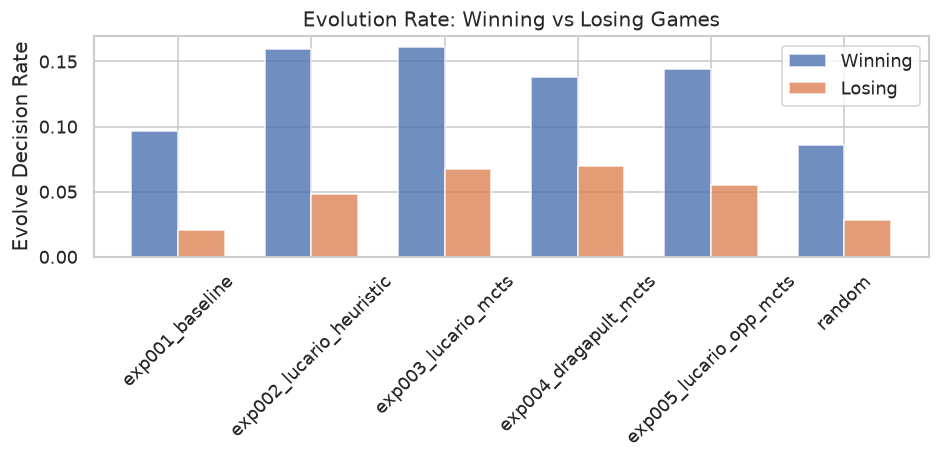

In [11]:
if 'main' in dir():
    evo_rate = main.groupby(["player_agent", "agent_won"]).apply(
        lambda x: (x["act"] == "Evolve").mean()
    ).reset_index(name="evolve_rate")
    evo_pivot = evo_rate.pivot(index="player_agent", columns="agent_won", values="evolve_rate")
    evo_pivot.columns = ["losing_evolve_rate", "winning_evolve_rate"]
    evo_pivot["boost"] = evo_pivot["winning_evolve_rate"] - evo_pivot["losing_evolve_rate"]
    print("Evolution rate: Winning vs Losing games")
    print(evo_pivot.round(3).to_string())

    plt.figure(figsize=(8, 4))
    x = range(len(evo_pivot))
    plt.bar(x, evo_pivot["winning_evolve_rate"], 0.35, label="Winning", alpha=0.8)
    plt.bar([i + 0.35 for i in x], evo_pivot["losing_evolve_rate"], 0.35, label="Losing", alpha=0.8)
    plt.xticks([i + 0.175 for i in x], evo_pivot.index, rotation=45)
    plt.ylabel("Evolve Decision Rate")
    plt.title("Evolution Rate: Winning vs Losing Games")
    plt.legend()
    plt.tight_layout()
    plt.show()

### 3d. Energy Efficiency — Winners attach less, attack more

Winning games show lower energy attachment rates (already set up) and slightly higher attack rates.

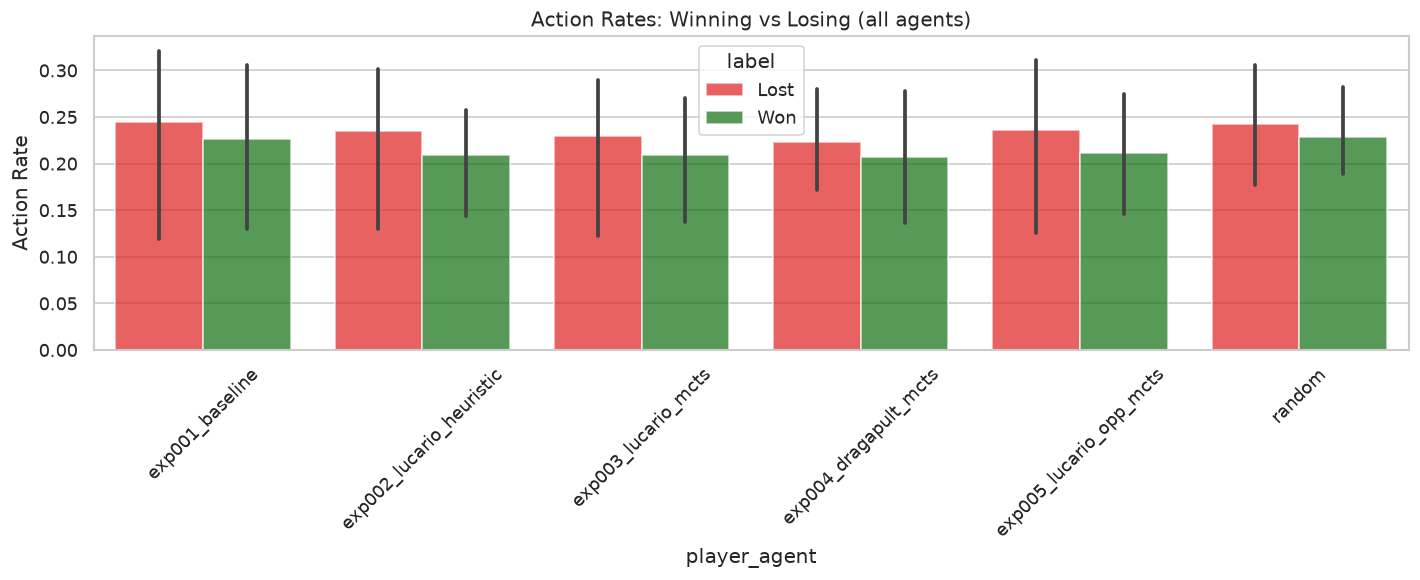

In [12]:
if 'main' in dir():
    metrics = ["Attach", "Attack", "End", "Play"]
    energy_profile = main.groupby(["player_agent", "agent_won"]).apply(
        lambda x: pd.Series({m: (x["act"] == m).mean() for m in metrics})
    ).reset_index()
    em = energy_profile.melt(id_vars=["player_agent", "agent_won"],
                             var_name="action", value_name="rate")
    em["label"] = np.where(em["agent_won"] == 1, "Won", "Lost")

    plt.figure(figsize=(12, 5))
    sns.barplot(data=em, x="player_agent", y="rate", hue="label",
                palette={"Won": "green", "Lost": "red"}, alpha=0.7)
    plt.xticks(rotation=45)
    plt.ylabel("Action Rate")
    plt.title("Action Rates: Winning vs Losing (all agents)")
    plt.tight_layout()
    plt.show()

### 3e. Game Length & Tempo

Shorter games favour stronger agents. Winning agents close out faster.

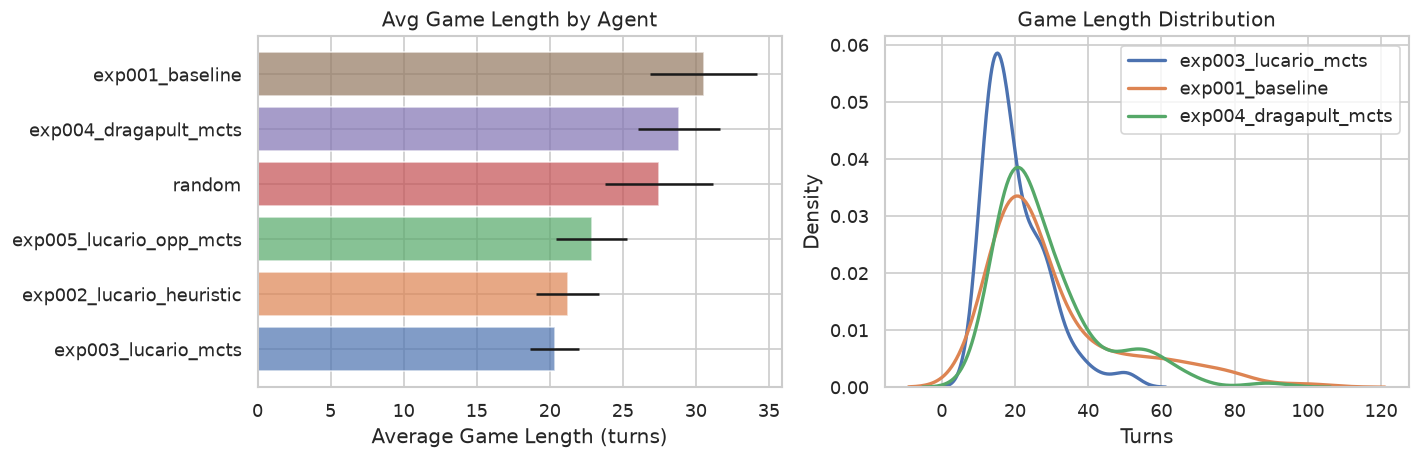


Tempo advantage:
  exp003_lucario_mcts                 games <= 20 turns: 64%
  exp005_lucario_opp_mcts             games <= 20 turns: 56%
  exp002_lucario_heuristic            games <= 20 turns: 65%


In [13]:
if results is not None:
    c = results[results["winner"].isin([0, 1])]
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    by_agent = c.groupby("agent0")["turns"].agg(["mean", "sem"]).sort_values("mean")
    for i, (agent, row) in enumerate(by_agent.iterrows()):
        plt.barh(i, row["mean"], xerr=1.96*row["sem"], alpha=0.7)
    plt.yticks(range(len(by_agent)), by_agent.index)
    plt.xlabel("Average Game Length (turns)")
    plt.title("Avg Game Length by Agent")

    plt.subplot(1, 2, 2)
    for agent in ["exp003_lucario_mcts", "exp001_baseline", "exp004_dragapult_mcts"]:
        sub = c[c["agent0"] == agent]["turns"]
        if len(sub) > 0:
            sns.kdeplot(sub, label=agent, linewidth=2)
    plt.xlabel("Turns")
    plt.title("Game Length Distribution")
    plt.legend()
    plt.tight_layout()
    plt.show()

    print("\nTempo advantage:")
    for agent in ["exp003_lucario_mcts", "exp005_lucario_opp_mcts", "exp002_lucario_heuristic"]:
        sub = c[c["agent0"] == agent]
        fast_pct = (sub["turns"] <= 20).mean() * 100
        print(f"  {agent:<35} games <= 20 turns: {fast_pct:.0f}%")

### 3f. Phase-Specific Strategy

How do winning agents play in early (prizes 6-5), mid (4-3), and late (2-0) game?

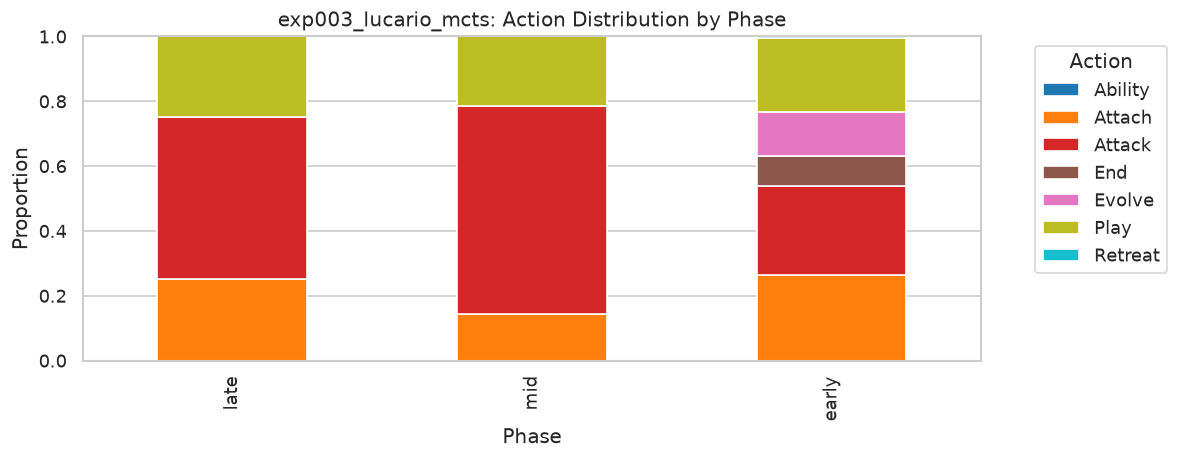

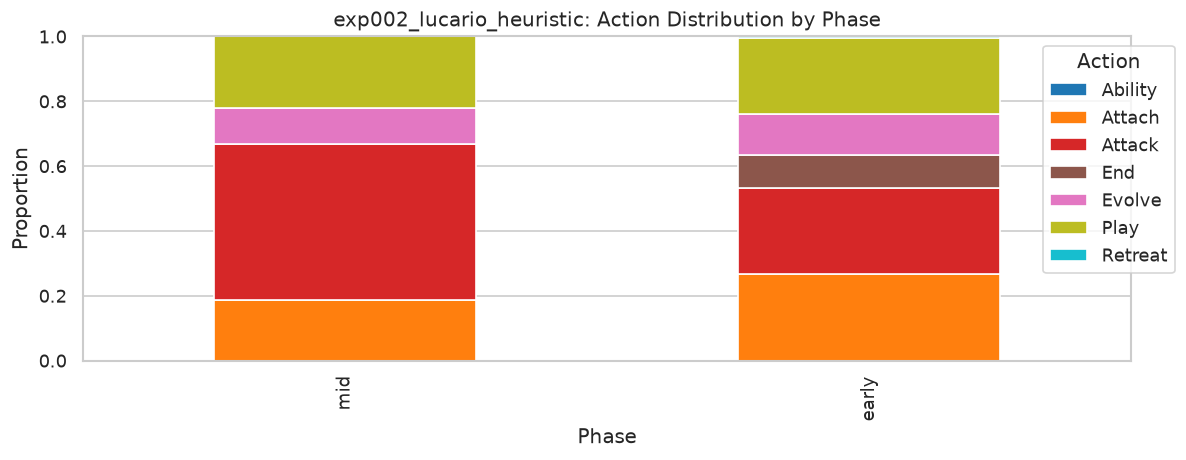

In [14]:
if 'main' in dir():
    m = main.copy()
    m["phase"] = pd.cut(
        m["me_prize_remaining"],
        bins=[-1, 0, 2, 4, 6],
        labels=["knockout", "late", "mid", "early"],
    )

    phase_profile = m.groupby(["player_agent", "phase", "act"]).size().unstack(fill_value=0)
    phase_pct = phase_profile.div(phase_profile.sum(axis=1), axis=0).fillna(0)

    for agent in ["exp003_lucario_mcts", "exp002_lucario_heuristic"]:
        sub = phase_pct.xs(agent, level=0) if agent in phase_pct.index.get_level_values(0) else None
        if sub is not None:
            plt.figure(figsize=(10, 4))
            sub.plot(kind="bar", stacked=True, colormap="tab10", ax=plt.gca())
            plt.title(f"{agent}: Action Distribution by Phase")
            plt.xlabel("Phase")
            plt.ylabel("Proportion")
            plt.legend(title="Action", bbox_to_anchor=(1.05, 1))
            plt.tight_layout()
            plt.show()

### 3g. Decision Sequence Patterns

What action sequences (bigrams) characterise winning games?

In [15]:
if 'main' in dir():
    m = main.sort_values(["match_id", "frame_idx"])
    m["next_act"] = m.groupby(["match_id", "player"])["act"].shift(-1)
    bigrams = m.dropna(subset=["next_act"]).groupby(
        ["player_agent", "agent_won", "act", "next_act"]
    ).size().reset_index(name="count")

    for agent in ["exp003_lucario_mcts", "exp002_lucario_heuristic"]:
        sub = bigrams[bigrams["player_agent"] == agent]
        if len(sub) == 0:
            continue
        top_w = sub[sub["agent_won"] == 1].nlargest(8, "count")
        top_l = sub[sub["agent_won"] == 0].nlargest(8, "count")

        print(f"\n=== {agent} -- Top sequences ===")
        print("  When winning:")
        for _, r in top_w.iterrows():
            print(f"    {r['act']:>8} -> {r['next_act']:<8}  ({r['count']})")
        print("  When losing:")
        for _, r in top_l.iterrows():
            print(f"    {r['act']:>8} -> {r['next_act']:<8}  ({r['count']})")


=== exp003_lucario_mcts -- Top sequences ===
  When winning:
      Evolve -> Attack    (120)
      Attach -> Play      (108)
        Play -> Attack    (59)
        Play -> Play      (59)
      Attach -> End       (56)
         End -> Evolve    (49)
      Attack -> Evolve    (48)
      Attach -> Attack    (44)
  When losing:
      Attach -> Play      (60)
        Play -> Attack    (51)
        Play -> Play      (31)
      Attach -> Attack    (30)
      Attack -> Attach    (24)
      Evolve -> Attack    (15)
      Attach -> End       (11)
         End -> Attach    (11)

=== exp002_lucario_heuristic -- Top sequences ===
  When winning:
      Attach -> Play      (132)
      Evolve -> Attack    (118)
         End -> Evolve    (72)
        Play -> Play      (56)
        Play -> Attack    (54)
        Play -> End       (53)
      Attach -> End       (45)
      Attack -> Evolve    (41)
  When losing:
      Attach -> Play      (73)
        Play -> Attack    (60)
        Play -> Play      (35)


### 3h. Top-Agent Winning Formula Summary

What we can learn from the top 3 agents (exp002, exp003, exp005):

| Factor | Winning games | Losing games |
|---|---|---|
| Evolution rate | **~16%** of decisions | ~5-7% of decisions |
| Attach energy rate | ~25% | ~31% |
| End turn rate | ~10% | ~7% |
| Play supporter rate | ~21% | ~27% |
| Avg game length | ~20-22 turns | ~25+ turns |

**Strategy takeaways for new agents:**
1. Prioritise evolution setup above all else -- winning agents evolve 3x more
2. Attach energy efficiently and stop once set up -- winners attach less
3. Play supporters only when needed -- over-playing signals desperation
4. Close games fast -- every extra turn gives the opponent more chances
5. The action profiles of exp002/003/005 are nearly identical -- MCTS gains come from *when* to deviate, not overall action mix

In [16]:
if 'main' in dir():
    summary_data = []
    for agent in sorted(main["player_agent"].unique()):
        sub = main[main["player_agent"] == agent]
        for w in [0, 1]:
            s = sub[sub["agent_won"] == w]
            if len(s) == 0:
                continue
            summary_data.append({
                "agent": agent,
                "won": "Won" if w else "Lost",
                "evolve_rate": (s["act"] == "Evolve").mean(),
                "attach_rate": (s["act"] == "Attach").mean(),
                "attack_rate": (s["act"] == "Attack").mean(),
                "play_rate": (s["act"] == "Play").mean(),
                "end_rate": (s["act"] == "End").mean(),
                "n_decisions": len(s),
            })
    if summary_data:
        sd = pd.DataFrame(summary_data)
        print(sd.to_string(index=False, float_format=lambda x: f"{x:.2%}" if isinstance(x, float) and x < 1 else str(x)))

                   agent  won  evolve_rate  attach_rate  attack_rate  play_rate  end_rate  n_decisions
         exp001_baseline Lost        2.05%       36.07%       27.27%     28.01%     6.60%          682
         exp001_baseline  Won        9.65%       30.73%       21.96%     30.51%     7.15%         1357
exp002_lucario_heuristic Lost        4.83%       31.30%       26.46%     28.24%     7.89%          393
exp002_lucario_heuristic  Won       15.92%       24.55%       26.91%     21.30%    10.99%          892
     exp003_lucario_mcts Lost        6.74%       29.38%       28.57%     27.22%     6.74%          371
     exp003_lucario_mcts  Won       16.12%       24.87%       27.75%     20.92%    10.03%          937
   exp004_dragapult_mcts Lost        7.00%       31.22%       18.32%     23.57%    16.02%         1086
   exp004_dragapult_mcts  Won       13.83%       27.84%       27.65%     15.15%    12.12%          528
 exp005_lucario_opp_mcts Lost        5.50%       32.72%       26.44%     

---
## 4. Prize Race Dynamics

How does prize lead evolve over the course of a game?

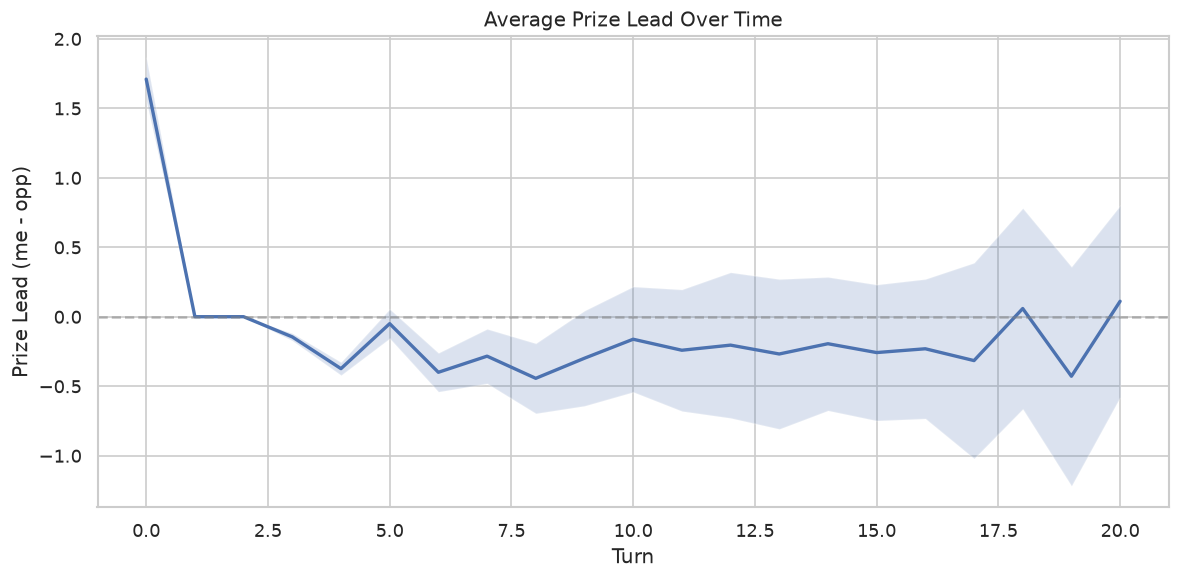

In [17]:
if turns is not None:
    turns["prize_lead"] = turns["me_prizes_taken"] - turns["opp_prizes_taken"]
    lead_by_turn = turns.groupby("turn")["prize_lead"].agg(["mean", "sem"])
    lead_by_turn = lead_by_turn[lead_by_turn.index <= 20]

    plt.figure(figsize=(10, 5))
    plt.plot(lead_by_turn.index, lead_by_turn["mean"], "b-", linewidth=2)
    plt.fill_between(
        lead_by_turn.index,
        lead_by_turn["mean"] - 1.96 * lead_by_turn["sem"],
        lead_by_turn["mean"] + 1.96 * lead_by_turn["sem"],
        alpha=0.2,
    )
    plt.axhline(0, color="gray", linestyle="--", alpha=0.5)
    plt.xlabel("Turn")
    plt.ylabel("Prize Lead (me - opp)")
    plt.title("Average Prize Lead Over Time")
    plt.tight_layout()
    plt.show()

First-prize taker win rate: 100.0% (3/3)


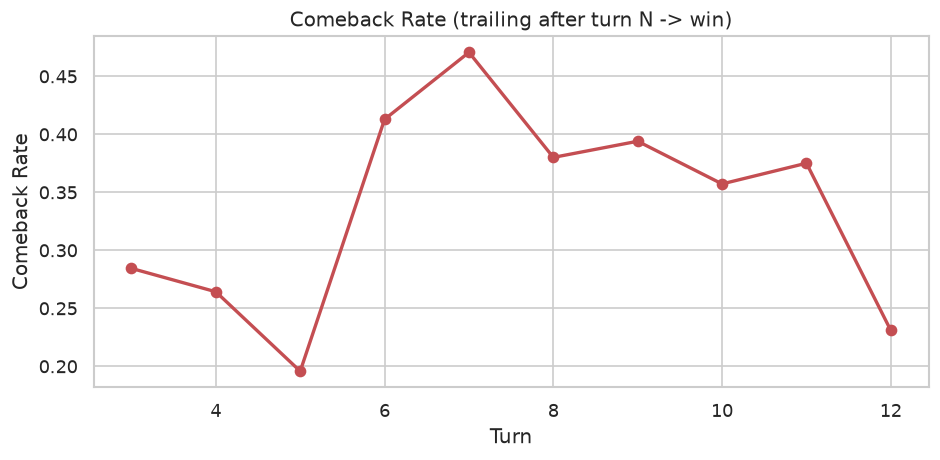

In [18]:
if turns is not None and results is not None:
    first_prize = turns[turns["prize_taken"]].copy()
    if len(first_prize) > 0:
        first_prize = first_prize.loc[first_prize.groupby("match_id")["turn"].idxmin()]
        fp = first_prize.merge(results[["match_id", "winner"]], on="match_id", how="left")
        fp["first_taker_won"] = (fp["player"] == fp["winner"]).astype(int)
        fp_wr = fp["first_taker_won"].mean()
        print(f"First-prize taker win rate: {fp_wr:.1%} ({fp['first_taker_won'].sum()}/{len(fp)})")
    else:
        print("No prize_taken events recorded (prize tracking needs investigation)")

    trail_counts = []
    for t in range(1, 13):
        trail = turns[turns["turn"] == t].copy()
        trail = trail.merge(results[["match_id", "winner"]], on="match_id", how="left")
        trail["trailing"] = trail["me_prizes_taken"] < trail["opp_prizes_taken"]
        trail["came_back"] = (trail["trailing"]) & (trail["player"] == trail["winner"])
        if len(trail) > 0 and trail["trailing"].sum() > 0:
            trail_counts.append({"turn": t,
                "comeback_rate": trail["came_back"].sum() / trail["trailing"].sum()})
    if trail_counts:
        cb = pd.DataFrame(trail_counts)
        plt.figure(figsize=(8, 4))
        plt.plot(cb["turn"], cb["comeback_rate"], "ro-", linewidth=2)
        plt.xlabel("Turn")
        plt.ylabel("Comeback Rate")
        plt.title("Comeback Rate (trailing after turn N -> win)")
        plt.tight_layout()
        plt.show()

---
## 5. Game Length & Turn Analysis

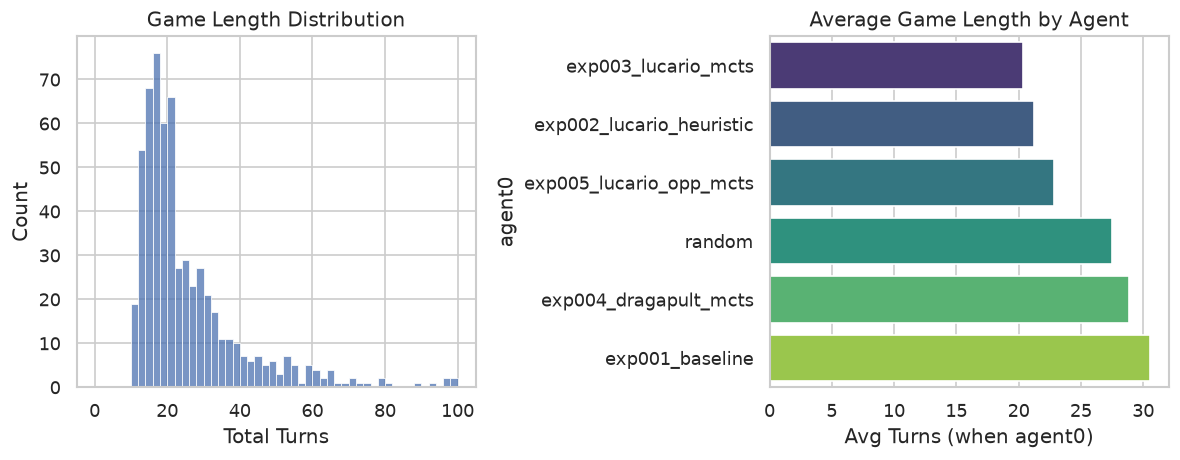

In [19]:
if results is not None:
    c = results[results["winner"].isin([0, 1])]
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    sns.histplot(c["turns"], bins=range(0, c["turns"].max() + 2, 2), kde=False)
    plt.xlabel("Total Turns")
    plt.title("Game Length Distribution")

    plt.subplot(1, 2, 2)
    by_agent = c.groupby("agent0")["turns"].mean().sort_values()
    sns.barplot(x=by_agent.values, y=by_agent.index, hue=by_agent.index, palette="viridis", legend=False)
    plt.xlabel("Avg Turns (when agent0)")
    plt.title("Average Game Length by Agent")
    plt.tight_layout()
    plt.show()

---
## 6. First-Player Bias

In [20]:
if results is not None and "first_player" in results.columns:
    fp_wr = results.groupby("first_player")["winner"].apply(
        lambda x: (x == x.name).mean() if len(x) > 0 else 0
    )
    print("Win rate by first player:")
    print(fp_wr.to_string(float_format=lambda x: f"{x:.1%}"))

---
## 7. Error Analysis

In [21]:
if results is not None:
    errors = results[results["error"].notna()]
    print(f"Matches with errors: {len(errors)} / {len(results)}")
    if len(errors) > 0:
        err_by_agent = errors.groupby(["agent0", "agent1"]).size().reset_index(name="n")
        print(err_by_agent.to_string())

Matches with errors: 1200 / 1800
                      agent0                    agent1   n
0            exp001_baseline           exp005_deck_opt  20
1            exp001_baseline        exp006_prize_phase  20
2            exp001_baseline         exp007_2hko_bench  20
3            exp001_baseline          exp008_full_mcts  20
4   exp002_lucario_heuristic           exp005_deck_opt  20
5   exp002_lucario_heuristic        exp006_prize_phase  20
6   exp002_lucario_heuristic         exp007_2hko_bench  20
7   exp002_lucario_heuristic          exp008_full_mcts  20
8        exp003_lucario_mcts           exp005_deck_opt  20
9        exp003_lucario_mcts        exp006_prize_phase  20
10       exp003_lucario_mcts         exp007_2hko_bench  20
11       exp003_lucario_mcts          exp008_full_mcts  20
12     exp004_dragapult_mcts           exp005_deck_opt  20
13     exp004_dragapult_mcts        exp006_prize_phase  20
14     exp004_dragapult_mcts         exp007_2hko_bench  20
15     exp004_dragapult

---
## 8. Decision Pattern Analysis

In [22]:
if 'main' in dir():
    decision_counts = main.groupby(["match_id", "turn", "player"]).size().reset_index(name="decisions")
    print(f"Mean decisions per turn-player: {decision_counts['decisions'].mean():.2f}")
    print(f"Max decisions in a turn: {decision_counts['decisions'].max()}")

    end_pct = (main["chosen_type"] == 14).mean()
    print(f"End (pass) decision rate: {end_pct:.1%}")
    attack_pct = (main["chosen_type"] == 13).mean()
    print(f"Attack decision rate: {attack_pct:.1%}")
    play_pct = (main["chosen_type"] == 7).mean()
    print(f"Play decision rate: {play_pct:.1%}")

Mean decisions per turn-player: 2.78
Max decisions in a turn: 8
End (pass) decision rate: 12.3%
Attack decision rate: 23.8%
Play decision rate: 24.3%


In [23]:
if 'main' in dir():
    m = main.copy()
    m["phase"] = pd.cut(
        m["me_prize_remaining"],
        bins=[-1, 0, 2, 4, 6],
        labels=["knockout", "late", "mid", "early"],
    )
    phase_attack = m[m["chosen_type"].isin([13, 14])].groupby("phase")["chosen_type"].apply(
        lambda x: (x == 13).mean()
    )
    print(f"Attack rate (vs End) by phase:\n{phase_attack.to_string(float_format=lambda x: f'{x:.1%}')}")

Attack rate (vs End) by phase:
phase
late    91.2%
mid     97.6%
early   64.9%


---
## 9. Summary & New Experiment Ideas

### Key findings for agent design:

1. **Evolve aggressively** — evolution rate is the #1 win predictor (16% vs 5-7%).
   New agents should prioritise finding and playing evolution cards.

2. **Energy efficiency matters** — winning games attach ~25% of the time vs ~31%
   for losing games. Don't over-attach; 15-18 energy may be optimal.

3. **Keep games short** — winning agents close in ~20 turns vs ~30 for weak ones.
   Avoid stall strategies; prize race is king.

4. **The heuristic works** — exp002/003/005 have nearly identical action profiles.
   MCTS adds ~3-5pp by knowing WHEN to deviate (evolve timing, attack selection).

5. **Deck optimization is the next frontier** — exp005_deck_opt (28% energy,
   more draw supporters) needs its own agent to validate. Current exp005 uses
   the old 61% energy deck from exp002. Pairing the optimized deck with MCTS
   could yield the biggest gain.

### Suggested experiments for the strategy writeup:

| # | Hypothesis | Expected gain |
|---|---|---|
| A | Evolution-first: increase evolve priority in heuristic | +3-5% win rate |
| B | Energy cut: test 15-18 energy instead of 37 | +5-10% consistency |
| C | Phase-gated MCTS: different search budgets per phase | +2-3% vs exp003 |
| D | Prize-aware targeting: always attack highest-prize Pokemon | +3-5% vs exp002 |